# Projeto de Python

No notebook a seguir, montaremos um portfólio de 10 ações e analisaremos tanto sua performance como algumas métricas de risco. O mesmo esta dividido em três partes...

Parte 1: Extração de Dados
* Download dos dados do Yahoo Finance
* Cálculo dos Retornos, Volatilidades e Betas dos ativos

Parte 2: Otimização Mean-Variance
* Otimização que maximiza o sharpe do portfólio
* Usa o método "SLSQP"

Parte 3: Gráficos & Métricas
* Cálculo de Metricas de risco do portfólio
* Plotagem dos gráficos

## Parte 1: Extração de dados

In [317]:
# Bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from scipy.optimize import minimize
from yfinance import download
from math import sqrt

In [318]:
data_inicial = "2022-01-03" # Ano - Mês - Dia
ativos_preco = download(
["MGLU3.SA",
"AZUL4.SA",
"BHIA3.SA",
"ENEV3.SA",
"BOVA11.SA",
"EMBR3.SA",
"PRIO3.SA",
"FHER3.SA",
"LOGN3.SA"],start=data_inicial)["Adj Close"]
ativos_preco.interpolate(method='linear',inplace=True) # substitui dados faltantes
retornos = ativos_preco.pct_change().dropna() # calcula o retorno percentual e elimina dados faltantes

[*********************100%%**********************]  9 of 9 completed


In [319]:
# calcula o beta com índices alinhados
def calcular_beta(ticker):
    datas_comum = retornos[ticker].index.intersection(retornos["BOVA11.SA"].index)
    retorno_ativo,retorno_ibov = retornos[ticker].align(retornos["BOVA11.SA"])
    return retorno_ativo.corr(retorno_ibov)
    
# dataframe com dados sobre os ativos
ativos_info = pd.DataFrame({
    "Retornos Médios Diários": [retornos[ticker].mean() for ticker in ativos_preco.columns],
    "Retornos Médios Anualizados": [retornos[ticker].mean() * 252 for ticker in ativos_preco.columns],
    "Volatilidade Diária": [retornos[ticker].std() for ticker in ativos_preco.columns],
    "Volatilidade Anualizada":[retornos[ticker].std() * sqrt(252) for ticker in ativos_preco.columns],
    "Beta" : [calcular_beta(ticker)* 0.01 for ticker in ativos_preco.columns]
                           }, index = [ticker for ticker in ativos_preco.columns])

ativos_info = np.round(ativos_info * 100,2) # arredonda dados para melhor visualização e compreensão
ativos_info

,Retornos Médios Diários,Retornos Médios Anualizados,Volatilidade Diária,Volatilidade Anualizada,Beta
AZUL4.SA,-0.08,-19.61,4.43,70.34,0.53
BHIA3.SA,-0.38,-94.55,4.87,77.38,0.44
BOVA11.SA,0.04,10.18,1.17,18.58,1.00
EMBR3.SA,0.12,29.67,2.53,40.14,0.26
ENEV3.SA,0.01,2.55,1.99,31.66,0.56
FHER3.SA,-0.17,-42.71,3.09,49.11,0.21
LOGN3.SA,0.11,28.75,2.94,46.75,0.40
MGLU3.SA,-0.16,-39.38,4.78,75.92,0.52
PRIO3.SA,0.17,41.77,2.51,39.89,0.43


## Parte 2: Otimização de Portfólio

In [321]:
# calcula os retornos diarios do portfolio
def retorno_portfolio(pesos): return retornos.dot(pesos)

# calcula a volatilidade diária,mensal e anual usando os retornos diários
def varianca_portfolio(pesos): 
    return retorno_portfolio(pesos).std(), retorno_portfolio(pesos).std() * sqrt(20), retorno_portfolio(pesos).std() * sqrt(252)

In [322]:
# calcula o sharpe anual do portfolio
def sharpe(pesos):
    taxa_livre = 0.1205
    retorno_anual = retorno_portfolio(pesos).mean() * 252
    volatilidade_anual = varianca_portfolio(pesos)[2]
    sharpe_ratio = (retorno_anual - taxa_livre) / volatilidade_anual
    return -sharpe_ratio

pesos_iniciais = np.array([.1,.1,.1,.1,.1,.1,.1,.1,.1]) # para inicializar o algoritmo de otimização
limites = tuple((0,(1/6)) for x in range(9)) # portfólio com, no mínimo, 6 ativos
restricao = {'type' : 'eq' , 'fun' : lambda pesos: np.sum(pesos) - 1} # soma dos pesos tem que ser igual a 0

In [323]:
max_sharpe = minimize(
    sharpe,pesos_iniciais,method='SLSQP',bounds=limites,constraints=(restricao)
                        ) # acha o portfolio com o maior índice de sharpe diário

pesos_otimos = max_sharpe["x"]

## Parte 3: Gráficos &  Métricas

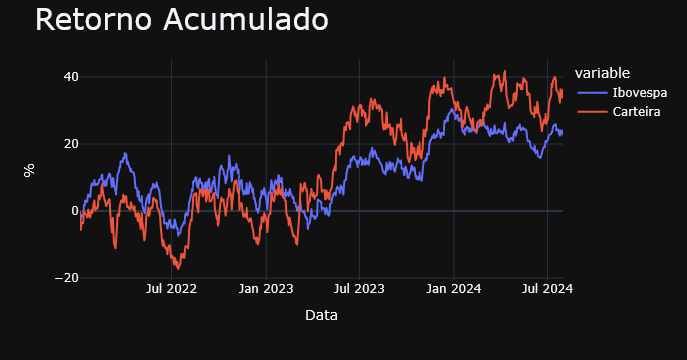

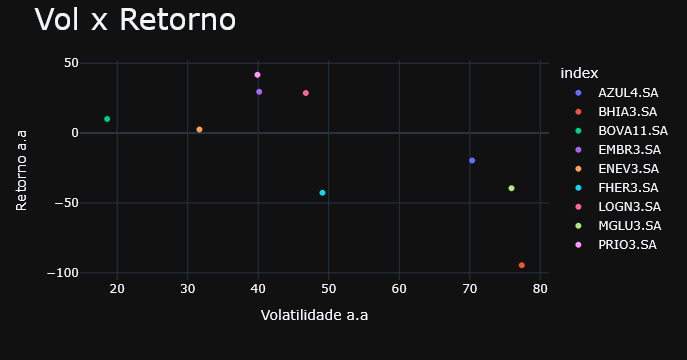

In [344]:
# calcula o retorno acumulado do portfólio ótimo
acumulado_carteira = (1 + retornos.dot(pesos_otimos)).cumprod() - 1
acumulado_carteira = acumulado_carteira * 100 # multiplica por 100 para melhor visualização

# calcula o retorno acumulado do ibovespa (BOVA11)
acumulado_ibov = (1 + retornos["BOVA11.SA"]).cumprod() - 1
acumulado_ibov = acumulado_ibov * 100

acumulado_total = pd.concat([acumulado_ibov,acumulado_carteira],axis=1)
acumulado_total.rename(columns={'BOVA11.SA':"Ibovespa",0:"Carteira"},inplace=True)
#acumulado_total.reset_index(inplace=True)

# desenha o gráfico de retorno acumulado para o período
grafico = px.line(acumulado_total,x=acumulado_total.index, y =["Ibovespa","Carteira"],template="plotly_dark") 
grafico.update_layout(title_font_size=30,title_text= "Retorno Acumulado",xaxis_title="Data",yaxis_title="%") # customização do gráfico
grafico.show()

# desenha o gráfico de Vol x Retorno
grafico_2 = px.scatter(ativos_info,x="Volatilidade Anualizada",y="Retornos Médios Anualizados",color=ativos_info.index,template="plotly_dark")
grafico_2.update_layout(title_font_size=30,title_text="Vol x Retorno",xaxis_title="Volatilidade a.a",yaxis_title="Retorno a.a")
grafico_2.show()